In [1]:
# 1. Install necessary libraries if you haven't already
# !pip install opencv-python numpy onnxruntime pandas matplotlib

import cv2
import numpy as np
import os
import pandas as pd
import onnxruntime as ort
import matplotlib.pyplot as plt
from datetime import datetime

# Configuration
CONFIDENCE_THRESHOLD = 0.50  # Similarity score to match a student
MODEL_PATH_YUNET = "models/yunet.onnx"
MODEL_PATH_ARCFACE = "models/arcface.onnx"
REGISTER_FOLDER = "CSM"
GROUP_PHOTO = "csm_group.jpeg"

print("✅ Libraries loaded successfully.")

✅ Libraries loaded successfully.


In [2]:
# --- CELL 2: LOAD MODELS (UPDATED FOR GROUP PHOTOS) ---
import cv2
import onnxruntime as ort

# Load ArcFace Model (Face Recognition)
arcface_session = ort.InferenceSession(
    MODEL_PATH_ARCFACE,
    providers=["CPUExecutionProvider"]
)
arcface_input_name = arcface_session.get_inputs()[0].name

# Helper Function: Load YuNet (Face Detection)
# UPDATED: Lowered score_threshold to 0.3 to find smaller/blurrier faces
def load_detector(image):
    h, w, _ = image.shape
    detector = cv2.FaceDetectorYN.create(
        MODEL_PATH_YUNET,
        "",
        (w, h),
        0.3,  # <--- CHANGED: Detection Threshold (was 0.6)
        0.3,  # NMS Threshold
        5000  # Top K
    )
    return detector

print("✅ AI Models initialized with High Sensitivity (Group Mode).")

✅ AI Models initialized with High Sensitivity (Group Mode).


In [3]:
# 1. Align Face (Rotates face so eyes are horizontal - Crucial for accuracy)
def align_face(image, landmarks):
    left_eye, right_eye = landmarks[0], landmarks[1]
    
    # Calculate angle
    dy = right_eye[1] - left_eye[1]
    dx = right_eye[0] - left_eye[0]
    angle = np.degrees(np.arctan2(dy, dx))
    
    # Get center and rotate
    eye_center = ((left_eye[0] + right_eye[0]) // 2, (left_eye[1] + right_eye[1]) // 2)
    M = cv2.getRotationMatrix2D(eye_center, angle, scale=1)
    aligned = cv2.warpAffine(image, M, (image.shape[1], image.shape[0]))
    return aligned

# 2. Get Embedding (Converts face pixels to a list of numbers)
def get_arcface_embedding(face_crop):
    # Preprocessing for ArcFace
    face_crop = cv2.resize(face_crop, (112, 112))
    face_crop = face_crop.astype(np.float32)
    face_crop = (face_crop - 127.5) / 128.0  # Normalize
    face_crop = np.transpose(face_crop, (2, 0, 1)) # HWC -> CHW
    face_crop = np.expand_dims(face_crop, axis=0)
    
    # Run Inference
    embedding = arcface_session.run(None, {arcface_input_name: face_crop})[0]
    return embedding.flatten()

In [4]:
# --- CELL 4: SMART REGISTRATION (Clean & Fast) ---
import os
import cv2
import numpy as np

# Storage
student_matrix_list = [] 
student_ids_list = []    
reference_images = {}    

# Configuration
MAX_IMAGES_PER_STUDENT = 15  # Good balance between speed & accuracy

print(f"📂 Scanning 'register' folder (Limit: {MAX_IMAGES_PER_STUDENT} imgs/student)...")

if not os.path.exists(REGISTER_FOLDER):
    print(f"❌ Error: Folder '{REGISTER_FOLDER}' not found.")
else:
    total_images = 0
    
    for student_id in os.listdir(REGISTER_FOLDER):
        # 1. SKIP SYSTEM FOLDERS (The Fix)
        if student_id.startswith("."): 
            continue
            
        student_path = os.path.join(REGISTER_FOLDER, student_id)
        
        if os.path.isdir(student_path):
            images = os.listdir(student_path)
            count = 0
            
            # Sort to ensure we get the same images every time
            images.sort()
            
            for img_name in images:
                # 2. CHECK FILE EXTENSION
                if not (img_name.lower().endswith(('.jpg', '.jpeg', '.png'))):
                    continue
                
                # 3. SMART LIMIT (Stop after 15 images to save time)
                if count >= MAX_IMAGES_PER_STUDENT:
                    break
                    
                img_path = os.path.join(student_path, img_name)
                img = cv2.imread(img_path)
                
                if img is None: continue
                
                # Detect
                detector = load_detector(img)
                _, faces = detector.detect(img)
                
                if faces is not None:
                    # Align & Crop
                    face = faces[0]
                    landmarks = face[4:14].reshape((5, 2))
                    aligned_img = align_face(img, landmarks)
                    
                    x, y, w, h = list(map(int, face[:4]))
                    face_crop = aligned_img[y:y+h, x:x+w]
                    
                    if face_crop.size > 0:
                        # Embed
                        emb = get_arcface_embedding(face_crop)
                        emb = emb / np.linalg.norm(emb)
                        
                        student_matrix_list.append(emb)
                        student_ids_list.append(student_id)
                        
                        # Save Reference
                        if student_id not in reference_images:
                            reference_images[student_id] = face_crop
                            
                        count += 1
                        total_images += 1

            print(f"  ✅ Registered: {student_id:<12} ({count} images)")

    # Build Matrix
    if student_matrix_list:
        student_matrix = np.array(student_matrix_list).T 
        print(f"\n🎉 Database Built! {total_images} total vectors stored.")
        
        # AUTO-SAVE (So you don't forget)
        import pickle
        model_data = {
            "matrix": student_matrix,
            "ids": student_ids_list,
            "references": reference_images
        }
        with open("trained_student_model.pkl", "wb") as f:
            pickle.dump(model_data, f)
        print("💾 Model automatically saved to 'trained_student_model.pkl'")
        
    else:
        print("❌ Error: No faces found.")

📂 Scanning 'register' folder (Limit: 15 imgs/student)...
  ✅ Registered: 23JR1A4201   (10 images)
  ✅ Registered: 23JR1A4202   (10 images)
  ✅ Registered: 23JR1A4203   (10 images)
  ✅ Registered: 23JR1A4204   (10 images)
  ✅ Registered: 23JR1A4205   (10 images)
  ✅ Registered: 23JR1A4206   (10 images)
  ✅ Registered: 23JR1A4207   (10 images)
  ✅ Registered: 23JR1A4208   (10 images)
  ✅ Registered: 23JR1A4209   (10 images)
  ✅ Registered: 23JR1A4210   (10 images)
  ✅ Registered: 23JR1A4211   (15 images)
  ✅ Registered: 23JR1A4212   (10 images)
  ✅ Registered: 23JR1A4213   (10 images)
  ✅ Registered: 23JR1A4214   (10 images)
  ✅ Registered: 23JR1A4215   (10 images)
  ✅ Registered: 23JR1A4216   (10 images)
  ✅ Registered: 23JR1A4217   (10 images)
  ✅ Registered: 23JR1A4218   (10 images)
  ✅ Registered: 23JR1A4219   (10 images)
  ✅ Registered: 23JR1A4220   (11 images)
  ✅ Registered: 23JR1A4221   (10 images)
  ✅ Registered: 23JR1A4222   (10 images)
  ✅ Registered: 23JR1A4225   (10 images)


🔄 Processing 'csm_group.jpeg' with BALANCED Logic...
   ✅ Detected 25 potential faces.

📊 Detailed Report:
            ID   Status     Score
3   23JR1A4201  Present  0.610682
15  23JR1A4204  Present  0.428427
10  23JR1A4206  Present  0.482655
6   23JR1A4208  Present  0.558329
1   23JR1A4218  Present  0.633304
14  23JR1A4219  Present  0.436154
9   23JR1A4226  Present  0.486483
16  23JR1A4228  Present  0.404077
12  23JR1A4229  Present  0.463041
5   23JR1A4235  Present  0.560802
11  23JR1A4236  Present  0.466300
13  23JR1A4237  Present  0.452936
0   23JR1A4238  Present  0.707114
4   23JR1A4244  Present  0.582499
17  23JR1A4247  Present  0.355648
2   23JR1A4251  Present  0.622604
7   23JR1A4257  Present  0.558226
8   23JR1A4258  Present  0.556489

📈 Recognition Rate: 72.0%


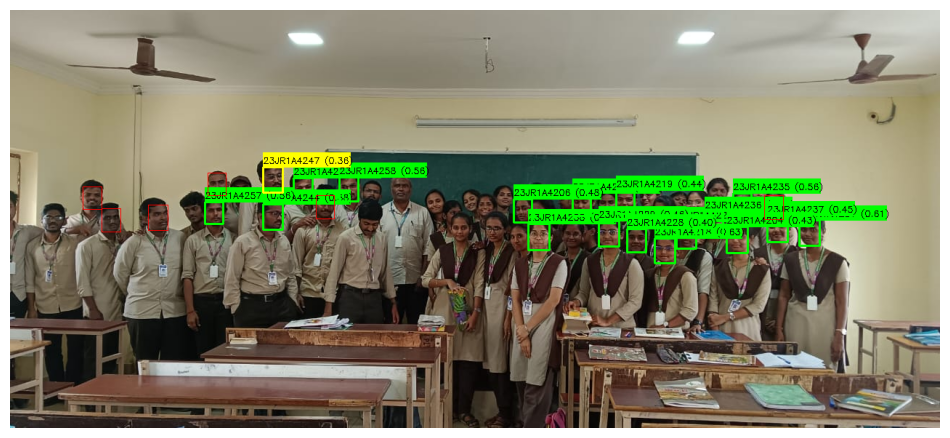

In [5]:
# --- CELL 5: FINAL DIAGNOSTIC TEST (BALANCED LOGIC) ---
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# 1. SETTINGS (Must match Cell 7 exactly)
CONFIDENCE_GREEN = 0.40   # Strict Safe Match
RESCUE_TIER_1    = 0.35   # Rescue if score is decent (Gap > 0.05)
RESCUE_TIER_2    = 0.30   # Rescue if score is low (Gap > 0.15)
DETECTOR_THRESH  = 0.5    # Lowered slightly to find faces (Safety comes from Ratio check)

# 2. LOAD IMAGE
if 'GROUP_PHOTO' not in globals(): GROUP_PHOTO = "girls group photo.jpeg"
img_raw = cv2.imread(GROUP_PHOTO)

# --- HELPER FUNCTIONS ---
def align_face(image, landmarks):
    left_eye, right_eye = landmarks[0], landmarks[1]
    dy = right_eye[1] - left_eye[1]
    dx = right_eye[0] - left_eye[0]
    angle = np.degrees(np.arctan2(dy, dx))
    eye_center = ((left_eye[0] + right_eye[0]) // 2, (left_eye[1] + right_eye[1]) // 2)
    M = cv2.getRotationMatrix2D(eye_center, angle, scale=1)
    return cv2.warpAffine(image, M, (image.shape[1], image.shape[0]))

def process_image_at_scale(image, target_width):
    h, w = image.shape[:2]
    scale = target_width / w
    new_h = int(h * scale)
    img_resized = cv2.resize(image, (target_width, new_h))
    
    lab = cv2.cvtColor(img_resized, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img_enhanced = cv2.cvtColor(cv2.merge((clahe.apply(l), a, b)), cv2.COLOR_LAB2BGR)
    
    detector = cv2.FaceDetectorYN.create(MODEL_PATH_YUNET, "", (target_width, new_h), DETECTOR_THRESH, 0.3, 5000)
    _, faces = detector.detect(img_enhanced)
    
    results = []
    if faces is not None:
        for face in faces:
            x, y, w_box, h_box = face[:4]
            x = int(x / scale); y = int(y / scale)
            w_box = int(w_box / scale); h_box = int(h_box / scale)
            
            # 1. Aspect Ratio Check (Kills Shoes/Walls)
            aspect_ratio = h_box / w_box
            if aspect_ratio < 0.75 or aspect_ratio > 1.6: continue 
            
            # 2. Size Check (Kills Tiny Noise)
            if w_box < 25 or h_box < 25: continue

            landmarks = face[4:14].reshape((5, 2)) / scale
            aligned_full = align_face(image, landmarks)
            face_crop = aligned_full[max(0,y):y+h_box, max(0,x):x+w_box]
            if face_crop.size == 0: continue

            emb = get_arcface_embedding(face_crop)
            emb = emb / np.linalg.norm(emb)
            scores = np.dot(emb, student_matrix)
            ranked = sorted(zip(scores, student_ids_list), reverse=True)
            
            results.append({
                "coords": (x, y, w_box, h_box),
                "name": ranked[0][1],
                "score": ranked[0][0],
                "gap": ranked[0][0] - (ranked[1][0] if len(ranked)>1 else 0)
            })
    return results

def clean_overlapping_boxes(candidates):
    candidates.sort(key=lambda x: x["score"], reverse=True)
    final_results = []
    used_indices = set()
    
    def get_iou(boxA, boxB):
        xA, yA = max(boxA[0], boxB[0]), max(boxA[1], boxB[1])
        xB, yB = min(boxA[0]+boxA[2], boxB[0]+boxB[2]), min(boxA[1]+boxA[3], boxB[1]+boxB[3])
        interArea = max(0, xB - xA) * max(0, yB - yA)
        boxAArea = boxA[2] * boxA[3]
        boxBArea = boxB[2] * boxB[3]
        return interArea / float(boxAArea + boxBArea - interArea)

    def get_center_dist(boxA, boxB):
        cA = (boxA[0] + boxA[2]//2, boxA[1] + boxA[3]//2)
        cB = (boxB[0] + boxB[2]//2, boxB[1] + boxB[3]//2)
        return np.sqrt((cA[0]-cB[0])**2 + (cA[1]-cB[1])**2)

    for i in range(len(candidates)):
        if i in used_indices: continue
        current = candidates[i]
        final_results.append(current)
        used_indices.add(i)
        for j in range(i+1, len(candidates)):
            if j in used_indices: continue
            if get_iou(current["coords"], candidates[j]["coords"]) > 0.30 or get_center_dist(current["coords"], candidates[j]["coords"]) < 30:
                used_indices.add(j)
    return final_results

# --- EXECUTION ---
if img_raw is None:
    print(f"❌ ERROR: Image '{GROUP_PHOTO}' not found.")
else:
    print(f"🔄 Processing '{GROUP_PHOTO}' with BALANCED Logic...")
    
    all_candidates = []
    all_candidates.extend(process_image_at_scale(img_raw, 1280)) # Standard
    all_candidates.extend(process_image_at_scale(img_raw, 2500)) # Deep Search
    
    final_results = clean_overlapping_boxes(all_candidates)
    
    display_img = img_raw.copy()
    attendance_log = []
    assigned_ids = set()
    
    print(f"   ✅ Detected {len(final_results)} potential faces.")
    
    for c in final_results:
        name, score, gap = c["name"], c["score"], c["gap"]
        x, y, w, h = c["coords"]
        status, color = "Unknown", (0, 0, 255) # Default Red
        
        if name in assigned_ids:
            status = "Duplicate"
        
        # --- BALANCED LOGIC ---
        elif score >= CONFIDENCE_GREEN:
            status, color = "Present", (0, 255, 0) # Green
            
        elif score >= RESCUE_TIER_1 and gap >= 0.05:
            status, color = "Present", (0, 255, 255) # Yellow (Tier 1)
            
        elif score >= RESCUE_TIER_2 and gap >= 0.15:
            status, color = "Present", (0, 255, 255) # Yellow (Tier 2)
            
        if status == "Present": assigned_ids.add(name)
        
        if status != "Duplicate":
            thick = 2 if status != "Unknown" else 1
            cv2.rectangle(display_img, (x, y), (x+w, y+h), color, thick)
            
            if status != "Unknown":
                cv2.rectangle(display_img, (x, y-20), (x+120, y), color, -1)
                cv2.putText(display_img, f"{name} ({score:.2f})", (x, y-5), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0,0,0), 1)
                attendance_log.append({"ID": name, "Status": status, "Score": score})

    # Show Output
    if attendance_log:
        df = pd.DataFrame(attendance_log).sort_values(by="ID")
        print("\n📊 Detailed Report:")
        print(df[["ID", "Status", "Score"]])
        
        print(f"\n📈 Recognition Rate: {(len(df)/len(final_results))*100:.1f}%")
    else:
        print("⚠️ No students recognized.")
        
    plt.figure(figsize=(12, 8))
    plt.imshow(cv2.cvtColor(display_img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()
    cv2.imwrite("diagnostic_result.jpg", display_img)

🔄 Analyzing Attendance for Batch 22JR1A42...


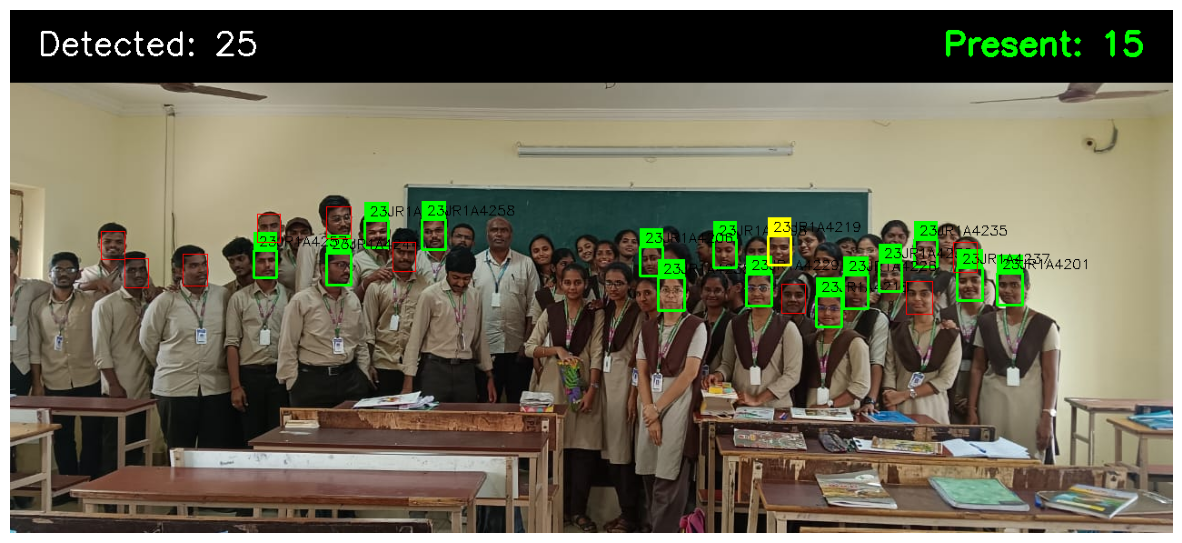


📝 GENERATING BATCH REPORT (22JR1A4201 - 66)...
    Student ID   Status
0   23JR1A4201  Present
1   23JR1A4202   Absent
2   23JR1A4203   Absent
3   23JR1A4204   Absent
4   23JR1A4205   Absent
5   23JR1A4206  Present
6   23JR1A4207   Absent
7   23JR1A4208  Present
8   23JR1A4209   Absent
9   23JR1A4210   Absent
10  23JR1A4211   Absent
11  23JR1A4212   Absent
12  23JR1A4213   Absent
13  23JR1A4214   Absent
14  23JR1A4215   Absent
15  23JR1A4216   Absent
16  23JR1A4217   Absent
17  23JR1A4218  Present
18  23JR1A4219  Present
19  23JR1A4220   Absent
20  23JR1A4221   Absent
21  23JR1A4222   Absent
22  23JR1A4223   Absent
23  23JR1A4224   Absent
24  23JR1A4225   Absent
25  23JR1A4226  Present
26  23JR1A4227   Absent
27  23JR1A4228   Absent
28  23JR1A4229  Present
29  23JR1A4230   Absent
30  23JR1A4231   Absent
31  23JR1A4232   Absent
32  23JR1A4233   Absent
33  23JR1A4234   Absent
34  23JR1A4235  Present
35  23JR1A4236  Present
36  23JR1A4237  Present
37  23JR1A4238  Present
38  23JR1A4239  

In [6]:
# --- CELL 6: DASHBOARD + SPECIFIC REPORT (22JR1A4201 - 66) ---
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

# 1. SETTINGS
CONFIDENCE_GREEN = 0.45   # Strict Match
RESCUE_TIER_1    = 0.40   # Rescue (High)
RESCUE_TIER_2    = 0.35   # Rescue (Low)
DETECTOR_THRESH  = 0.5    

# 2. LOAD IMAGE
image_path = GROUP_PHOTO
if not os.path.exists(image_path):
    print(f"❌ Error: Image '{image_path}' not found.")
    img_raw = None
else:
    img_raw = cv2.imread(image_path)

# --- HELPER FUNCTIONS ---
def align_face(image, landmarks):
    left_eye, right_eye = landmarks[0], landmarks[1]
    dy = right_eye[1] - left_eye[1]
    dx = right_eye[0] - left_eye[0]
    angle = np.degrees(np.arctan2(dy, dx))
    eye_center = ((left_eye[0] + right_eye[0]) // 2, (left_eye[1] + right_eye[1]) // 2)
    M = cv2.getRotationMatrix2D(eye_center, angle, scale=1)
    return cv2.warpAffine(image, M, (image.shape[1], image.shape[0]))

def process_image_at_scale(image, target_width):
    h, w = image.shape[:2]
    scale = target_width / w
    new_h = int(h * scale)
    img_resized = cv2.resize(image, (target_width, new_h))
    
    # ENHANCE
    lab = cv2.cvtColor(img_resized, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img_enhanced = cv2.cvtColor(cv2.merge((clahe.apply(l), a, b)), cv2.COLOR_LAB2BGR)
    
    detector = cv2.FaceDetectorYN.create(MODEL_PATH_YUNET, "", (target_width, new_h), DETECTOR_THRESH, 0.3, 5000)
    _, faces = detector.detect(img_enhanced)
    
    results = []
    if faces is not None:
        for face in faces:
            x, y, w_box, h_box = face[:4]
            x = int(x / scale); y = int(y / scale)
            w_box = int(w_box / scale); h_box = int(h_box / scale)
            
            # Aspect Ratio & Size Checks
            aspect_ratio = h_box / w_box
            if aspect_ratio < 0.75 or aspect_ratio > 1.6: continue 
            if w_box < 25 or h_box < 25: continue

            landmarks = face[4:14].reshape((5, 2)) / scale
            aligned_full = align_face(image, landmarks)
            face_crop = aligned_full[max(0,y):y+h_box, max(0,x):x+w_box]
            if face_crop.size == 0: continue

            # RECOGNITION
            emb = get_arcface_embedding(face_crop)
            emb = emb / np.linalg.norm(emb)
            scores = np.dot(emb, student_matrix)
            best_idx = np.argmax(scores)
            max_score = scores[best_idx]
            
            sorted_scores = sorted(scores, reverse=True)
            gap = sorted_scores[0] - sorted_scores[1] if len(sorted_scores) > 1 else 0

            results.append({
                "coords": (x, y, w_box, h_box),
                "name": student_ids_list[best_idx],
                "score": max_score,
                "gap": gap
            })
    return results

def clean_overlapping_boxes(candidates):
    candidates.sort(key=lambda x: x["score"], reverse=True)
    final = []
    used_indices = set()
    for i in range(len(candidates)):
        if i in used_indices: continue
        current = candidates[i]
        final.append(current)
        used_indices.add(i)
        for j in range(i+1, len(candidates)):
            if j in used_indices: continue
            xA = max(current["coords"][0], candidates[j]["coords"][0])
            yA = max(current["coords"][1], candidates[j]["coords"][1])
            xB = min(current["coords"][0]+current["coords"][2], candidates[j]["coords"][0]+candidates[j]["coords"][2])
            yB = min(current["coords"][1]+current["coords"][3], candidates[j]["coords"][1]+candidates[j]["coords"][3])
            interArea = max(0, xB - xA) * max(0, yB - yA)
            boxAArea = current["coords"][2] * current["coords"][3]
            boxBArea = candidates[j]["coords"][2] * candidates[j]["coords"][3]
            iou = interArea / float(boxAArea + boxBArea - interArea)
            
            cA = (current["coords"][0] + current["coords"][2]//2, current["coords"][1] + current["coords"][3]//2)
            cB = (candidates[j]["coords"][0] + candidates[j]["coords"][2]//2, candidates[j]["coords"][1] + candidates[j]["coords"][3]//2)
            dist = np.sqrt((cA[0]-cB[0])**2 + (cA[1]-cB[1])**2)

            if iou > 0.30 or dist < 30:
                used_indices.add(j)
    return final

# --- EXECUTION ---
if img_raw is not None:
    print(f"🔄 Analyzing Attendance for Batch 22JR1A42...")
    
    # 1. PROCESS IMAGE
    all_candidates = []
    all_candidates.extend(process_image_at_scale(img_raw, 1280)) 
    all_candidates.extend(process_image_at_scale(img_raw, 2500)) 
    final_results = clean_overlapping_boxes(all_candidates)
    
    # 2. DRAW IMAGE
    display_img = img_raw.copy()
    img_h, img_w, _ = display_img.shape
    present_ids_set = set() # Stores IDs of students marked present
    
    for c in final_results:
        name, score, gap = c["name"], c["score"], c["gap"]
        x, y, w, h = c["coords"]
        
        status = "Unknown"
        color = (0, 0, 255)
        
        if name in present_ids_set:
            status = "Duplicate"
        elif score >= CONFIDENCE_GREEN:
            status, color = "Present", (0, 255, 0)
        elif score >= RESCUE_TIER_1 and gap >= 0.05:
            status, color = "Present", (0, 255, 255)
        elif score >= RESCUE_TIER_2 and gap >= 0.15:
            status, color = "Present", (0, 255, 255)

        if status == "Present":
            # Normalize ID to uppercase just in case
            present_ids_set.add(name.upper())
            cv2.rectangle(display_img, (x, y), (x+w, y+h), color, 2)
            cv2.rectangle(display_img, (x, y-20), (x+w, y), color, -1)
            cv2.putText(display_img, f"{name}", (x+5, y-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,0,0), 1)
        elif status == "Unknown":
            cv2.rectangle(display_img, (x, y), (x+w, y+h), color, 1)

    # 3. DRAW DASHBOARD BANNER
    cv2.rectangle(display_img, (0, 0), (img_w, 80), (0, 0, 0), -1)
    cv2.putText(display_img, f"Detected: {len(final_results)}", (30, 50), 
                cv2.FONT_HERSHEY_SIMPLEX, 1.2, (255, 255, 255), 2)
    text_present = f"Present: {len(present_ids_set)}"
    (text_w, text_h), _ = cv2.getTextSize(text_present, cv2.FONT_HERSHEY_SIMPLEX, 1.2, 2)
    cv2.putText(display_img, text_present, (img_w - text_w - 30, 50), 
                cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 255, 0), 3)

    plt.figure(figsize=(15, 10))
    plt.imshow(cv2.cvtColor(display_img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

    # --- 4. GENERATE SPECIFIC REPORT (22JR1A4201 - 22JR1A4266) ---
    print("\n📝 GENERATING BATCH REPORT (22JR1A4201 - 66)...")
    
    id_prefix = "23JR1A42"
    report_data = []
    
    # Loop from 1 to 66
    for i in range(1, 67):
        # Create ID: 22JR1A42 + 01, 02...
        student_id = f"{id_prefix}{i:02d}"
        
        # Check if this specific ID was in the 'present_ids_set'
        if student_id in present_ids_set:
            status = "Present"
        else:
            status = "Absent"
            
        report_data.append({"Student ID": student_id, "Status": status})

    # Display Report
    df_report = pd.DataFrame(report_data)
    
    # Save to CSV
    csv_filename = "attendance_23JR1A42.csv"
    df_report.to_csv(csv_filename, index=False)
    
    # Print Full Table
    pd.set_option('display.max_rows', None) # Show all rows
    print(df_report)
    print(f"\n✅ Report saved as '{csv_filename}'")

In [7]:
# --- SAVE THE TRAINED MODEL ---
import pickle

# We wrap everything into one dictionary
model_data = {
    "matrix": student_matrix,          # The math vectors
    "ids": student_ids_list,           # The names
    "references": reference_images     # The images for XAI overlay
}

# Save to a file (Serialize)
filename = "trained_csm_model.pkl"
with open(filename, "wb") as f:
    pickle.dump(model_data, f)

print(f"✅ Model Saved Successfully as '{filename}'")
print(f"💾 File Size: {os.path.getsize(filename) / 1024:.2f} KB")
print("You can now close the notebook and skip the registration step next time!")

✅ Model Saved Successfully as 'trained_csm_model.pkl'
💾 File Size: 1536.11 KB
You can now close the notebook and skip the registration step next time!


In [8]:
# --- LOAD THE TRAINED MODEL (FAST START) ---
import pickle
import os
import sys

filename = "trained_csm_model.pkl"

if os.path.exists(filename):
    print(f"📂 Loading saved model from '{filename}'...")
    
    with open(filename, "rb") as f:
        data = pickle.load(f)
        
    # Restore variables
    student_matrix = data["matrix"]
    student_ids_list = data["ids"]
    reference_images = data.get("references", {}) # .get() avoids crash if key missing
    
    print(f"🎉 Model Loaded! Ready to recognize {len(set(student_ids_list))} students.")
    print(f"🧠 Matrix Shape: {student_matrix.shape}")

else:
    print(f"❌ Error: '{filename}' not found.")
    print("👉 Please run the 'Registration' cell first to build and save the model.")

📂 Loading saved model from 'trained_csm_model.pkl'...
🎉 Model Loaded! Ready to recognize 52 students.
🧠 Matrix Shape: (512, 527)


In [9]:
# --- CELL 7: FINAL "BALANCED" PIPELINE (With Dashboard + Batch Report) ---
import cv2
import numpy as np
import pandas as pd
import pickle
import os
import onnxruntime as ort
import matplotlib.pyplot as plt
from datetime import datetime

# 1. LOAD MODEL
if os.path.exists("trained_csm_model.pkl"):
    with open("trained_csm_model.pkl", "rb") as f:
        data = pickle.load(f)
    student_matrix = data["matrix"]
    student_ids_list = data["ids"]
    print("✅ Student Database Loaded.")
else:
    print("❌ Error: Model not found.")

# 2. SETUP
MODEL_PATH_YUNET = "models/yunet.onnx"
MODEL_PATH_ARCFACE = "models/arcface.onnx"
arcface_session = ort.InferenceSession(MODEL_PATH_ARCFACE, providers=["CPUExecutionProvider"])
arcface_input_name = arcface_session.get_inputs()[0].name

# 3. HELPER FUNCTIONS
def get_arcface_embedding(face_crop):
    face_crop = cv2.resize(face_crop, (112, 112))
    face_crop = face_crop.astype(np.float32)
    face_crop = (face_crop - 127.5) / 128.0
    face_crop = np.transpose(face_crop, (2, 0, 1))
    face_crop = np.expand_dims(face_crop, axis=0)
    return arcface_session.run(None, {arcface_input_name: face_crop})[0].flatten()

def align_face(image, landmarks):
    left_eye, right_eye = landmarks[0], landmarks[1]
    dy = right_eye[1] - left_eye[1]
    dx = right_eye[0] - left_eye[0]
    angle = np.degrees(np.arctan2(dy, dx))
    eye_center = ((left_eye[0] + right_eye[0]) // 2, (left_eye[1] + right_eye[1]) // 2)
    M = cv2.getRotationMatrix2D(eye_center, angle, scale=1)
    return cv2.warpAffine(image, M, (image.shape[1], image.shape[0]))

def process_image_at_scale(image, target_width):
    h, w = image.shape[:2]
    scale = target_width / w
    new_h = int(h * scale)
    img_resized = cv2.resize(image, (target_width, new_h))
    
    lab = cv2.cvtColor(img_resized, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img_enhanced = cv2.cvtColor(cv2.merge((clahe.apply(l), a, b)), cv2.COLOR_LAB2BGR)
    
    detector = cv2.FaceDetectorYN.create(MODEL_PATH_YUNET, "", (target_width, new_h), 0.5, 0.3, 5000)
    _, faces = detector.detect(img_enhanced)
    
    results = []
    if faces is not None:
        for face in faces:
            x, y, w_box, h_box = face[:4]
            x = int(x / scale); y = int(y / scale)
            w_box = int(w_box / scale); h_box = int(h_box / scale)
            
            aspect_ratio = h_box / w_box
            if aspect_ratio < 0.75 or aspect_ratio > 1.6: continue 
            if w_box < 25 or h_box < 25: continue

            landmarks = face[4:14].reshape((5, 2)) / scale
            aligned_full = align_face(image, landmarks)
            face_crop = aligned_full[max(0,y):y+h_box, max(0,x):x+w_box]
            if face_crop.size == 0: continue

            emb = get_arcface_embedding(face_crop)
            emb = emb / np.linalg.norm(emb)
            scores = np.dot(emb, student_matrix)
            best_idx = np.argmax(scores)
            max_score = scores[best_idx]
            ranked = sorted(zip(scores, student_ids_list), reverse=True)
            
            results.append({
                "coords": (x, y, w_box, h_box),
                "name": ranked[0][1],
                "score": ranked[0][0],
                "gap": ranked[0][0] - (ranked[1][0] if len(ranked)>1 else 0)
            })
    return results

def clean_overlapping_boxes(candidates):
    candidates.sort(key=lambda x: x["score"], reverse=True)
    final_results = []
    used_indices = set()
    
    for i in range(len(candidates)):
        if i in used_indices: continue
        current = candidates[i]
        final_results.append(current)
        used_indices.add(i)
        for j in range(i+1, len(candidates)):
            if j in used_indices: continue
            # IOU Logic
            xA = max(current["coords"][0], candidates[j]["coords"][0])
            yA = max(current["coords"][1], candidates[j]["coords"][1])
            xB = min(current["coords"][0]+current["coords"][2], candidates[j]["coords"][0]+candidates[j]["coords"][2])
            yB = min(current["coords"][1]+current["coords"][3], candidates[j]["coords"][1]+candidates[j]["coords"][3])
            interArea = max(0, xB - xA) * max(0, yB - yA)
            boxAArea = current["coords"][2] * current["coords"][3]
            boxBArea = candidates[j]["coords"][2] * candidates[j]["coords"][3]
            iou = interArea / float(boxAArea + boxBArea - interArea)
            
            # Distance Logic
            cA = (current["coords"][0] + current["coords"][2]//2, current["coords"][1] + current["coords"][3]//2)
            cB = (candidates[j]["coords"][0] + candidates[j]["coords"][2]//2, candidates[j]["coords"][1] + candidates[j]["coords"][3]//2)
            dist = np.sqrt((cA[0]-cB[0])**2 + (cA[1]-cB[1])**2)

            if iou > 0.30 or dist < 30:
                used_indices.add(j)
    return final_results

# 5. MAIN FUNCTION (UPDATED)
def mark_attendance(image_path):
    print(f"\n🔄 Analyzing: {image_path}...")
    if not os.path.exists(image_path):
        print("❌ File not found.")
        return

    img_raw = cv2.imread(image_path)
    all_candidates = []

    # --- A. MULTI-SCALE DETECTION ---
    print("   1. Standard View (1280px)...")
    all_candidates.extend(process_image_at_scale(img_raw, 1280))
    print("   2. Deep Search (2500px)...")
    all_candidates.extend(process_image_at_scale(img_raw, 2500))

    # --- B. CLEAN DUPLICATES ---
    final_results = clean_overlapping_boxes(all_candidates)

    # --- C. DRAW RESULTS & DASHBOARD ---
    display_img = img_raw.copy()
    img_h, img_w = display_img.shape[:2]
    assigned_ids = set()
    
    print(f"   ✅ Processed {len(final_results)} faces.")

    for c in final_results:
        name, score, gap = c["name"], c["score"], c["gap"]
        x, y, w, h = c["coords"]
        
        status, color = "Unknown", (0, 0, 255) # Default Red
        
        if name in assigned_ids:
             status = "Duplicate"
        
        # --- TIERED LOGIC ---
        elif score >= 0.45:
            status, color = "Present", (0, 255, 0) # Green
        elif score >= 0.40 and gap >= 0.05:
            status, color = "Present", (0, 255, 255) # Yellow Tier 1
        elif score >= 0.35 and gap >= 0.15:
            status, color = "Present", (0, 255, 255) # Yellow Tier 2

        if status == "Present": 
            assigned_ids.add(name)
        
        # --- DRAW BOXES ---
        if status != "Duplicate":
            thick = 2 if status != "Unknown" else 1
            cv2.rectangle(display_img, (x, y), (x+w, y+h), color, thick)
            
            if status != "Unknown":
                # Label Background
                cv2.rectangle(display_img, (x, y-20), (x+w, y), color, -1)
                cv2.putText(display_img, name, (x+5, y-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,0,0), 1)

    # --- D. DRAW DASHBOARD BANNER (NEW) ---
    banner_height = 80
    cv2.rectangle(display_img, (0, 0), (img_w, banner_height), (0, 0, 0), -1)
    
    # Left: Total Detected
    cv2.putText(display_img, f"Detected: {len(final_results)}", (30, 50), 
                cv2.FONT_HERSHEY_SIMPLEX, 1.2, (255, 255, 255), 2)
    
    # Right: Present Count
    text_present = f"Present: {len(assigned_ids)}"
    (text_w, text_h), _ = cv2.getTextSize(text_present, cv2.FONT_HERSHEY_SIMPLEX, 1.2, 2)
    cv2.putText(display_img, text_present, (img_w - text_w - 30, 50), 
                cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 255, 0), 3)

    # Show Image
    plt.figure(figsize=(15, 10))
    plt.imshow(cv2.cvtColor(display_img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

    # --- E. GENERATE BATCH REPORT (22JR1A4201 - 66) ---
    print("\n📝 GENERATING BATCH REPORT (22JR1A4201 - 66)...")
    id_prefix = "22JR1A42"
    report_data = []
    
    for i in range(1, 67):
        # Create ID: 22JR1A42 + 01, 02...
        student_id = f"{id_prefix}{i:02d}"
        
        if student_id in assigned_ids:
            stat = "Present"
        else:
            stat = "Absent"
            
        report_data.append({"Student ID": student_id, "Status": stat})

    df = pd.DataFrame(report_data)
    
    # Save Dynamic Filename
    base_name = os.path.splitext(os.path.basename(image_path))[0]
    csv_name = f"Report_{base_name}.csv"
    df.to_csv(csv_name, index=False)
    
    # Print Summary
    print(f"✅ Full Report saved as '{csv_name}'")
    print(f"📈 Total Present: {len(assigned_ids)}")

✅ Student Database Loaded.


📂 Enter the name of the image file (e.g., girls group photo.jpeg):  csm_image.jpeg



🔄 Analyzing: csm_image.jpeg...
   1. Standard View (1280px)...
   2. Deep Search (2500px)...
   ✅ Processed 20 faces.


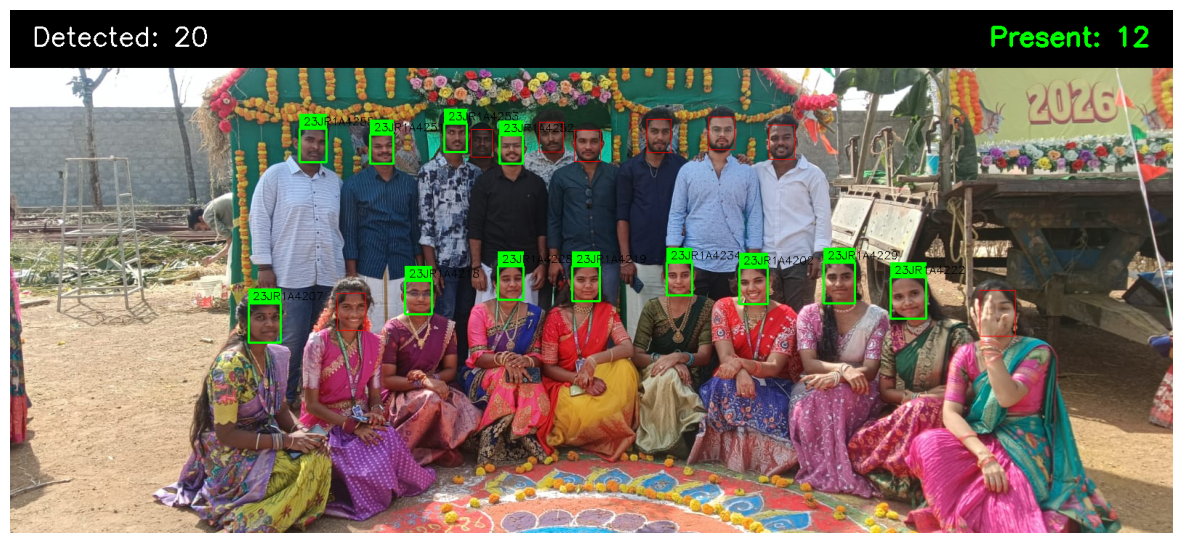


📝 GENERATING BATCH REPORT (22JR1A4201 - 66)...
✅ Full Report saved as 'Report_csm_image.csv'
📈 Total Present: 12


In [11]:
# --- CELL 8: RUN THE SYSTEM ---

# 1. Ask user for input
image_path = input("📂 Enter the name of the image file (e.g., girls group photo.jpeg): ")

# 2. Run the Pipeline
mark_attendance(image_path)